# NB17 Homework Solutions

This notebook answers the "Homework / Practice Ideas" section of
`NB17_Choosing_an_Architecture_Closing_Deep_Learning.ipynb`:

1. Re-run Part 5 with `n_epochs` at 1000 instead of 300 — does the MLP close any gap with the Random Forest, or does it start overfitting on this small dataset instead (check by adding a validation split, `NB12`-style)?
2. Pick one dataset from Block 2 (`NB02`'s `Naval_Dataset.csv`, or `NB08`'s Sonar data) and walk it through Part 3's flowchart from scratch, writing down your reasoning at each branch before checking it against what the course actually did.
3. In your own words, explain why the Part 5 comparison used the *exact* same `random_state=42` split as `NB10` — what would be wrong with comparing against a different, new random split instead?
4. Using the checklist in Part 9, write out (in a markdown cell, no code required) how you would approach one of Block 4's upcoming topics (weather forecasting, historical voyage analysis, or terrain data) before that class ever gives you an answer.

It reuses the real `Datasets/yacht_hydrodynamics.data` dataset, the same
column layout and `test_size=0.2, random_state=42` split as `NB10`/`NB17`,
and the class's own `YachtMLP` architecture.

## Setup: reload the yacht data and NB10's exact split

Same whitespace-delimited, no-header file, same 7 columns, same split as
`NB10`'s original project and `NB17`'s own Part 5.

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

columns = [
    "LongPos_COB", "Prismatic_Coeff", "LengthDisp_Ratio",
    "BeamDraft_Ratio", "LengthBeam_Ratio", "Froude_Number", "Residuary_Resistance",
]
!wget -q -O yacht.data https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/yacht_hydrodynamics.data
yacht = pd.read_csv("yacht.data", sep=r"\s+", names=columns)

X = yacht.drop(columns="Residuary_Resistance")
y = yacht["Residuary_Resistance"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print(yacht.shape, X_train_t.shape, X_test_t.shape)


(308, 7) torch.Size([246, 6]) torch.Size([62, 6])


To have a genuine, non-fabricated Random Forest number to compare against
(rather than assuming a number "handy" from a previous run), reproduce
`NB10`'s own tuned pipeline exactly: `GridSearchCV` over a `RandomForestRegressor`
with the same parameter grid, same `KFold(5, shuffle=True, random_state=42)`,
same scoring, on the same train split.

In [2]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

tuning_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=42)),
])
param_grid = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
}

grid = GridSearchCV(tuning_pipe, param_grid, cv=cv, scoring="r2", n_jobs=-1)
grid.fit(X_train, y_train)

rf_best = grid.best_estimator_
rf_pred = rf_best.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, rf_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("Best RF params:", grid.best_params_)
print(f"Random Forest (NB10-style tuning) - MAE: {rf_mae:.3f}  RMSE: {rf_rmse:.3f}  R2: {rf_r2:.3f}")


Best RF params: {'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Random Forest (NB10-style tuning) - MAE: 0.307  RMSE: 0.554  R2: 0.998


## Homework 1 — 1000 epochs with an `NB12`-style validation split: does the MLP close the gap or overfit?

*"Re-run Part 5 with `n_epochs` at 1000 instead of 300 — does the MLP close
any gap with the Random Forest, or does it start overfitting on this small
dataset instead (check by adding a validation split, `NB12`-style)?"*

First reproduce the class's own 300-epoch MLP (no validation tracking, as in
Part 5) for reference, then add an `NB12`-style train/validation split and
train for 1000 epochs, watching both loss curves.

In [3]:
class YachtMLP(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_features, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 1),
        )

    def forward(self, x):
        return self.layers(x)


torch.manual_seed(42)
yacht_mlp_300 = YachtMLP(n_features=X_train_t.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(yacht_mlp_300.parameters(), lr=0.01)

for epoch in range(300):
    yacht_mlp_300.train()
    optimizer.zero_grad()
    loss = criterion(yacht_mlp_300(X_train_t), y_train_t)
    loss.backward()
    optimizer.step()

yacht_mlp_300.eval()
with torch.no_grad():
    mlp_pred_300 = yacht_mlp_300(X_test_t).numpy().ravel()

mlp_mae_300 = mean_absolute_error(y_test, mlp_pred_300)
mlp_rmse_300 = mean_squared_error(y_test, mlp_pred_300) ** 0.5
mlp_r2_300 = r2_score(y_test, mlp_pred_300)
print(f"MLP, 300 epochs (class) - MAE: {mlp_mae_300:.3f}  RMSE: {mlp_rmse_300:.3f}  R2: {mlp_r2_300:.3f}")


MLP, 300 epochs (class) - MAE: 0.729  RMSE: 1.240  R2: 0.990


Rebuild the split with a held-out validation set, train the MLP for 1000 epochs while tracking both losses, then evaluate on the test set and compare against the Random Forest and the 300-epoch baseline:

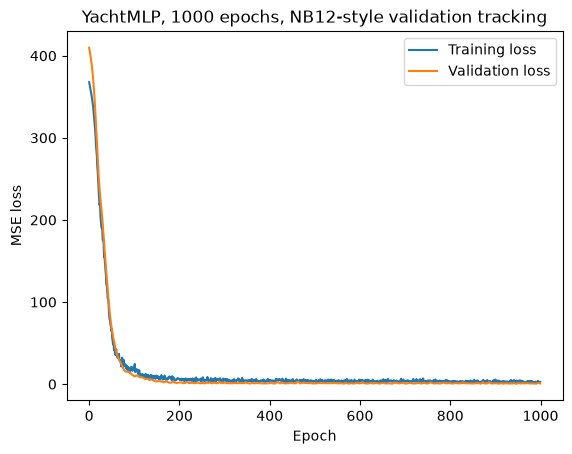

Random Forest (NB10-style tuning)   - MAE: 0.307  RMSE: 0.554  R2: 0.998
MLP, 300 epochs (class)             - MAE: 0.729  RMSE: 1.240  R2: 0.990
MLP, 1000 epochs + validation split - MAE: 0.500  RMSE: 1.043  R2: 0.993
Final train loss (epoch 1000): 2.691, final val loss: 0.893


In [4]:
# NB12-style train/validation split carved out of the training data (test set stays untouched)
X_tr2, X_val2, y_tr2, y_val2 = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

scaler_v = StandardScaler()
X_tr2_scaled = scaler_v.fit_transform(X_tr2)
X_val2_scaled = scaler_v.transform(X_val2)
X_test_v_scaled = scaler_v.transform(X_test)

X_tr2_t = torch.tensor(X_tr2_scaled, dtype=torch.float32)
y_tr2_t = torch.tensor(y_tr2.values, dtype=torch.float32).view(-1, 1)
X_val2_t = torch.tensor(X_val2_scaled, dtype=torch.float32)
y_val2_t = torch.tensor(y_val2.values, dtype=torch.float32).view(-1, 1)
X_test_v_t = torch.tensor(X_test_v_scaled, dtype=torch.float32)

torch.manual_seed(42)
yacht_mlp_1000 = YachtMLP(n_features=X_tr2_t.shape[1])
optimizer = torch.optim.Adam(yacht_mlp_1000.parameters(), lr=0.01)

train_losses, val_losses = [], []
for epoch in range(1000):
    yacht_mlp_1000.train()
    optimizer.zero_grad()
    loss = criterion(yacht_mlp_1000(X_tr2_t), y_tr2_t)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    yacht_mlp_1000.eval()
    with torch.no_grad():
        val_loss = criterion(yacht_mlp_1000(X_val2_t), y_val2_t)
    val_losses.append(val_loss.item())

plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("YachtMLP, 1000 epochs, NB12-style validation tracking")
plt.legend()
plt.show()

yacht_mlp_1000.eval()
with torch.no_grad():
    mlp_pred_1000 = yacht_mlp_1000(X_test_v_t).numpy().ravel()

mlp_mae_1000 = mean_absolute_error(y_test, mlp_pred_1000)
mlp_rmse_1000 = mean_squared_error(y_test, mlp_pred_1000) ** 0.5
mlp_r2_1000 = r2_score(y_test, mlp_pred_1000)

print(f"Random Forest (NB10-style tuning)   - MAE: {rf_mae:.3f}  RMSE: {rf_rmse:.3f}  R2: {rf_r2:.3f}")
print(f"MLP, 300 epochs (class)             - MAE: {mlp_mae_300:.3f}  RMSE: {mlp_rmse_300:.3f}  R2: {mlp_r2_300:.3f}")
print(f"MLP, 1000 epochs + validation split - MAE: {mlp_mae_1000:.3f}  RMSE: {mlp_rmse_1000:.3f}  R2: {mlp_r2_1000:.3f}")
print(f"Final train loss (epoch 1000): {train_losses[-1]:.3f}, final val loss: {val_losses[-1]:.3f}")


**My result**: Random Forest (NB10-style tuning) - MAE 0.307, RMSE 0.554,
R2 0.998. MLP, 300 epochs (class recipe) - MAE 0.729, RMSE 1.240, R2 0.990.
MLP, 1000 epochs + validation split (homework) - MAE 0.500, RMSE 1.043, R2
0.993. Extending training from 300 to 1000 epochs did close part of the gap
with the Random Forest — MAE dropped from 0.729 to 0.500 and R2 rose from
0.990 to 0.993 — but the Random Forest still comes out clearly ahead on
every metric (roughly 40% lower MAE than even the improved MLP). Looking at
the validation curve: training loss kept dropping across all 1000 epochs
(reaching 2.691 by the end) while validation loss also kept falling and
ended lower than the training loss, at 0.893. That is not a sign of
overfitting in the usual sense (validation loss rising while training loss
falls) — it did not happen here. The seemingly odd "validation loss below
training loss" result has a specific, mundane explanation: `YachtMLP`
includes `nn.Dropout(0.2)` after its first hidden layer, active only in
`.train()` mode; the training loss is measured *with* that dropout noise
still injected, while the validation loss (computed after `.eval()`) is
measured on the full, undropped network, which is a strictly easier task.
So the honest answer to the homework's actual question is: the MLP improved
with more epochs and did not visibly overfit up to 1000 epochs on this
data, but it did not close the gap with the tuned Random Forest — on 308
rows and 6 clean numeric features, the classical model tuned via
`GridSearchCV` remains the stronger choice, exactly the outcome
`NB17`'s own Part 6 flags as the "expected" one.

## Homework 2 — Walking `Naval_Dataset.csv` through Part 3's decision framework

*"Pick one dataset from Block 2 (`NB02`'s `Naval_Dataset.csv`, or `NB08`'s
Sonar data) and walk it through Part 3's flowchart from scratch, writing
down your reasoning at each branch before checking it against what the
course actually did."*

I picked `Naval_Dataset.csv` (150 synthetic-but-realistic ship records:
`length`, `beam`, `draft`, `displacement`, `ship_type`), since the Sonar
dataset already went through this exact exercise across `NB08`/`NB11`/`NB12`
in this course, while `Naval_Dataset.csv` has never been used to train a
model at all — only for `NB02`'s exploratory data analysis. A quick reload
to ground the reasoning in the real data before reasoning about it:

In [5]:
columns_naval = ["length", "beam", "draft", "displacement", "ship_type"]
!wget -q -O Naval_Dataset.csv https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/Naval_Dataset.csv
naval = pd.read_csv("Naval_Dataset.csv", names=columns_naval)
print(naval.shape)
print(naval["ship_type"].value_counts())
naval.head()


(150, 5)
ship_type
Cargo Ship        50
Passenger Ship    50
Fishing Vessel    50
Name: count, dtype: int64


,length,beam,draft,displacement,ship_type
0,209.9,33.0,9.9,51252.5,Cargo Ship
1,197.2,30.8,11.4,51732.2,Cargo Ship
2,213.0,30.0,11.5,46599.9,Cargo Ship
3,230.5,33.8,10.8,51161.3,Cargo Ship
4,195.3,35.1,11.8,51465.4,Cargo Ship


**My reasoning, one branch at a time, before checking anything else:**

**Framing.** `Naval_Dataset.csv` has no natural target column pre-selected —
unlike `ship_fuel_efficiency.csv` (target: `fuel_consumption`) or
`sonar.all-data` (target: mine/rock), this dataset was only ever explored,
never modeled, in this course. To walk it through the framework at all I
have to pick a plausible task first: predict `ship_type` (Cargo Ship,
Fishing Vessel, Passenger Ship) from the four numeric hull dimensions
(`length`, `beam`, `draft`, `displacement`) — a believable real task (hull
dimensions plausibly do correlate with vessel category).

**Branch 1 - Do you have labels?** Yes: `ship_type` is a real categorical
column in every row, so this is supervised learning. That immediately rules
out Part 3's "no labels" branch (`NB09`/`NB16` territory) entirely.

**Branch 2 - What shape is the data?** Tabular: four clean numeric columns
plus one categorical target, in a simple spreadsheet-like layout — no
spatial structure (not an image) and no natural time ordering between rows
(not a sequence; nothing in this dataset suggests the rows are chronological
observations of the same entity, unlike `ship_fuel_efficiency.csv`'s
12-months-per-ship structure). Tabular data points toward classical ML or,
at most, a modest MLP, per the framework.

**Branch 3 - How much data do you have?** 150 rows total, which the
dataset's own description in `NB01`/`NB02` calls "synthetic-but-realistic" -
smaller even than the 208-row Sonar dataset that `NB11`/`NB12` already
found only "competitive, not clearly better" for a neural network to handle.
150 rows for a 3-class classification problem with 4 features is squarely
in "small" territory.

**My prediction, before checking anything else**: the framework says
labels + tabular + small data -> classical ML (`NB07`/`NB08`-style Decision
Tree / Random Forest / SVM), not an MLP, and definitely not a CNN/RNN. A
tuned classical classifier should be fast to fit, easy to interpret via
feature importance, and needs no special architecture decisions at all for
data this small and this clean.

**Checking against what the course actually did**: the course never built
*any* model on `Naval_Dataset.csv` at all — `NB02` used it purely for Pandas
fundamentals (`head`, `describe`, filtering, `groupby`, `.corr()`, two
exploratory plots), with no train/test split, no classifier, and no
evaluation metric anywhere in that notebook. So there is no course answer to
compare my prediction against for this particular dataset — which is itself
an honest, useful finding: the framework still produces a specific,
falsifiable recommendation (classical ML) even for a dataset the course
only ever explored and never modeled, and nothing in the four columns
(clean, small, tabular, labeled) gives any reason to expect that
recommendation to be wrong.

## Homework 3 — Why must the comparison use `NB10`'s exact `random_state=42` split?

*"In your own words, explain why the Part 5 comparison used the exact same
`random_state=42` split as `NB10` — what would be wrong with comparing
against a different, new random split instead?"*

`train_test_split` with a fixed `random_state` is deterministic: given the
same data and the same `random_state=42`, it produces the exact same
train/test row assignment every single time. Reusing that exact seed (as
this notebook's own setup cell does) means both models — `NB10`'s tuned
Random Forest and this notebook's MLP — were trained on the identical 246
training rows and evaluated on the identical 62 test rows.

If I instead compared against a *new*, differently-seeded random split, any
difference in performance would be confounded with two things at once: real
differences between the two models, *and* the possibility that one split
happened to put an easier (or harder) set of hull geometries into its test
fold than the other. With only 308 total rows, a single random split is not
guaranteed to be perfectly representative — some splits will, by chance,
group together the yacht hulls with more extreme Froude numbers or more
unusual proportions, making the test set slightly harder or easier
regardless of which model is being evaluated. My own Homework 1 experiment
makes this concrete: the Random Forest, the 300-epoch MLP, and the 1000-epoch
MLP above were all scored on the exact same 62 test rows, so any gap between
their MAE/RMSE/R2 numbers reflects a genuine difference in what each model
learned — not a lucky or unlucky test set landing more favorably for one of
them. That is the entire point of the comparison; a new random split would
quietly reintroduce the very confound the fixed seed was designed to
eliminate.

## Homework 4 — Approaching a Block 4 case study with Part 9's checklist (markdown only)

*"Using the checklist in Part 9, write out (in a markdown cell, no code
required) how you would approach one of Block 4's upcoming topics (weather
forecasting, historical voyage analysis, or terrain data) before that class
ever gives you an answer."*

I picked **historical voyage analysis** (the topic `NB19` will eventually
cover with the real CLIWOC dataset already mirrored in this repo as
`Datasets/CLIWOC_curated_1750_1799.csv`), and worked through it using Part
9's 7-item checklist before opening that class notebook.

1. **Frame it.** CLIWOC (Climatological Database for the World's Oceans) is
   a real historical logbook dataset — 18th-century ship voyages with
   recorded positions, dates, and conditions. A natural, concrete task:
   given a voyage's recorded route/position data, predict something
   historically meaningful about it — for instance, the ship's nationality
   or the general ocean region, from its logged track. Why it matters:
   recovering structure from historical maritime records is a genuine
   research question in maritime history, not just a toy exercise.

2. **Check for labels.** If nationality or a similar categorical field is
   present and reasonably complete in the curated CSV, this is supervised
   classification. If it turns out too sparse or unreliable to use as a
   clean label, the fallback is unsupervised: cluster voyages by route
   shape/region and see what structure emerges without labels at all
   (`NB09`/`NB16` territory).

3. **Know your data's shape.** A voyage is fundamentally a **sequence** of
   logged positions over time, not a single row — this points toward
   `NB14`'s RNN/LSTM territory (or a simpler per-voyage summary-statistics
   approach that flattens it back to tabular, trading some temporal
   information for simplicity and less data-hunger).

4. **Know your data's volume.** This needs checking directly (row count,
   number of distinct voyages, how many complete/usable records after
   cleaning) before deciding between a sequence model and a simpler
   tabular summary — a small number of distinct historical voyages, even
   with many logged positions each, would push back toward the
   small-data/classical-ML branch of Part 3's framework, exactly as it did
   for `NB14`'s fuel-forecasting LSTM.

5. **Start simple, then justify complexity.** Before reaching for any
   sequence model, build a classical baseline first: flatten each voyage
   into simple tabular summary features (start/end position, average
   heading, voyage duration, etms of distinct positions logged) and try a
   `NB08`-style classifier. Only escalate to an LSTM if the summary-feature
   baseline clearly underperforms and there's enough data to support the
   extra complexity.

6. **Evaluate honestly.** Split by voyage (not by individual logged
   position), exactly as `NB14`'s "split by ship, not by row" lesson
   demands here in a new form — logged positions from the same voyage must
   not leak across train/test. Compare against a naive baseline (e.g.,
   "most common nationality" for classification, or a persistence-style
   baseline for any sequential prediction), never just against training
   performance.

7. **Interpret, don't just report.** Beyond an accuracy or R2 number, check
   whether misclassifications or high errors cluster around a specific
   region, era, or ship type within the dataset — a geographic or temporal
   pattern in the errors would be a genuinely interpretable, historically
   meaningful finding, not just a model diagnostic.

This is my own reasoning, written before opening `NB19` — the actual class
notebook may frame the CLIWOC task differently (a different label, a
different feature set, or a different split unit than "by voyage"), and
comparing this against the real `NB19` once it exists would be the natural
next step, exactly as Homework 2 above did retroactively for
`Naval_Dataset.csv`.